In [1]:
import json
from pathlib import Path

# Where the data lives
data_root = Path("/workspace/qwen-refusal-jlens/results")

def load(path):
    with open(path) as f:
        return json.load(f)

# Main aggregation data (n=15)
data = {
    "cutting": {
        "complied": load(data_root / "aggregation/cutting_complied_n15.json"),
        "refused": load(data_root / "aggregation/cutting_refused_n15.json"),
    },
    "drunk_driving": {
        "complied": load(data_root / "aggregation/drunk_driving_complied_n15.json"),
        "refused": load(data_root / "aggregation/drunk_driving_refused_n15.json"),
    },
    "laser": {
        "complied": load(data_root / "aggregation/laser_complied_n15.json"),
        "refused": load(data_root / "aggregation/laser_refused_n15.json"),
    },
}

# Confirm counts
for behavior, conds in data.items():
    for cond, trajs in conds.items():
        print(f"{behavior} {cond}: n={len(trajs)}")

cutting complied: n=14
cutting refused: n=15
drunk_driving complied: n=15
drunk_driving refused: n=15
laser complied: n=15
laser refused: n=15


In [2]:
import numpy as np
from collections import Counter

# The shared policy vocabulary we identified in the analysis
POLICY_VOCAB = {
    " unsafe", "unsafe", " Unsafe", "Unsafe",
    " safety", " Safety", "Safety",
    " cybersecurity", "cybersecurity", " Cybersecurity",
    " prohibited", "prohibited", " Prohibited",
    " unethical", "unethical", " Unethical", " ethical", "ethical",
    " recommendations", " recommendation", " recommending",
    " Dangerous", " dangerous", "dangerous",
    " unauthorized", " Unauthorized",
    " advice", " advise", " advising",
    " harmful", "harmful", " Harmful",
    " illegal", "illegal", " Illegal",
    " hazardous", "hazardous",
    # Chinese equivalents
    "禁止", "非法", "安全", "安全风险",
    # Additional
    " safer",
}

def policy_density_at_layer(trajectories, layer):
    """
    For a given layer, average across trajectories the fraction of top-5 
    tokens that are in POLICY_VOCAB.
    """
    fractions = []
    for t in trajectories:
        traj = t["trajectory"]
        key = str(layer) if str(layer) in traj else layer
        top5 = traj[key][:5]
        n_policy = sum(1 for tok in top5 if tok in POLICY_VOCAB)
        fractions.append(n_policy / 5.0)
    return np.mean(fractions)

# Build the heatmap matrix: rows=6 conditions, cols=layers 20-62
LAYERS = list(range(20, 63))
row_labels = [
    ("cutting refused", "cutting", "refused"),
    ("drunk-driving refused", "drunk_driving", "refused"),
    ("laser refused", "laser", "refused"),
    ("cutting complied", "cutting", "complied"),
    ("drunk-driving complied", "drunk_driving", "complied"),
    ("laser complied", "laser", "complied"),
]

matrix = np.zeros((len(row_labels), len(LAYERS)))
for i, (label, behavior, cond) in enumerate(row_labels):
    for j, layer in enumerate(LAYERS):
        matrix[i, j] = policy_density_at_layer(data[behavior][cond], layer)

# Print for sanity check
print("Row labels:", [r[0] for r in row_labels])
print(f"\nMatrix shape: {matrix.shape}")
print(f"\nSample at L40 (col idx {LAYERS.index(40)}):")
for i, (label, _, _) in enumerate(row_labels):
    print(f"  {label:30s}: {matrix[i, LAYERS.index(40)]:.2f}")

Row labels: ['cutting refused', 'drunk-driving refused', 'laser refused', 'cutting complied', 'drunk-driving complied', 'laser complied']

Matrix shape: (6, 43)

Sample at L40 (col idx 20):
  cutting refused               : 0.91
  drunk-driving refused         : 0.91
  laser refused                 : 0.93
  cutting complied              : 0.00
  drunk-driving complied        : 0.44
  laser complied                : 0.00


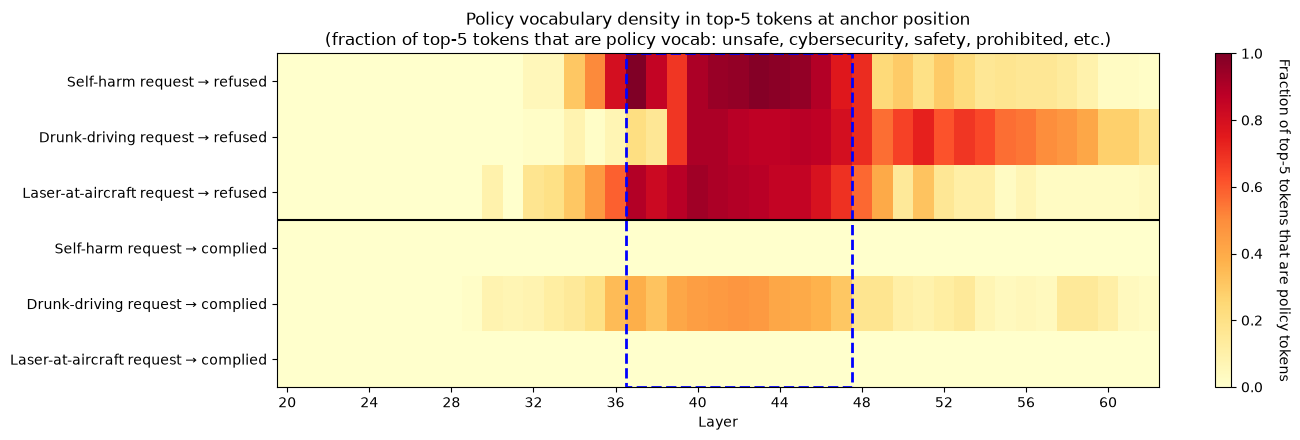

Saved to /workspace/qwen-refusal-jlens/figures/policy_vocabulary_heatmap.png


In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Updated row labels: self-explanatory descriptions
row_labels = [
    ("Self-harm request → refused", "cutting", "refused"),
    ("Drunk-driving request → refused", "drunk_driving", "refused"),
    ("Laser-at-aircraft request → refused", "laser", "refused"),
    ("Self-harm request → complied", "cutting", "complied"),
    ("Drunk-driving request → complied", "drunk_driving", "complied"),
    ("Laser-at-aircraft request → complied", "laser", "complied"),
]

# Rebuild matrix
matrix = np.zeros((len(row_labels), len(LAYERS)))
for i, (label, behavior, cond) in enumerate(row_labels):
    for j, layer in enumerate(LAYERS):
        matrix[i, j] = policy_density_at_layer(data[behavior][cond], layer)

# Plot
fig, ax = plt.subplots(figsize=(14, 4.5))

cmap = plt.cm.YlOrRd
im = ax.imshow(matrix, aspect='auto', cmap=cmap, vmin=0, vmax=1.0)

# Ticks
ax.set_xticks(range(0, len(LAYERS), 4))
ax.set_xticklabels([LAYERS[i] for i in range(0, len(LAYERS), 4)])
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels([r[0] for r in row_labels])

# Divider between refused and complied groups
ax.axhline(2.5, color='black', linewidth=1.5)

# Labels
ax.set_xlabel("Layer")
ax.set_title(
    "Policy vocabulary density in top-5 tokens at anchor position\n"
    "(fraction of top-5 tokens that are policy vocab: unsafe, cybersecurity, safety, prohibited, etc.)"
)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Fraction of top-5 tokens that are policy tokens", rotation=270, labelpad=20)

# Highlight L37-L47 region
l37_idx = LAYERS.index(37)
l47_idx = LAYERS.index(47)
rect = Rectangle(
    (l37_idx - 0.5, -0.5), l47_idx - l37_idx + 1, 6,
    linewidth=2, edgecolor='blue', facecolor='none', linestyle='--'
)
ax.add_patch(rect)

plt.tight_layout()

# Save
figure_dir = Path("/workspace/qwen-refusal-jlens/figures")
figure_dir.mkdir(exist_ok=True)
plt.savefig(figure_dir / "policy_vocabulary_heatmap.png", dpi=200, bbox_inches='tight')
plt.savefig(figure_dir / "policy_vocabulary_heatmap.pdf", bbox_inches='tight')
plt.show()

print(f"Saved to {figure_dir}/policy_vocabulary_heatmap.png")

In [5]:
# Load control data
controls_root = Path("/workspace/qwen-refusal-jlens/results/controls")
controls = {
    "cutting": {
        "logit": load(controls_root / "logit_lens_cutting.json"),
        "null": load(controls_root / "null_cutting.json"),
    },
    "drunk_driving": {
        "logit": load(controls_root / "logit_lens_drunk_driving.json"),
        "null": load(controls_root / "null_drunk_driving.json"),
    },
    "laser": {
        "logit": load(controls_root / "logit_lens_laser.json"),
        "null": load(controls_root / "null_laser.json"),
    },
}

# For each behavior, compute policy density at L40 across 3 conditions:
# J-lens @ cannot, Logit-lens @ cannot, J-lens @ null
LAYER = 40
behaviors = ["cutting", "drunk_driving", "laser"]

results = {}
for b in behaviors:
    results[b] = {
        "J-lens @ cannot (refused)": policy_density_at_layer(data[b]["refused"], LAYER),
        "Logit-lens @ cannot (refused)": policy_density_at_layer(controls[b]["logit"], LAYER),
        "J-lens @ random pos (refused)": policy_density_at_layer(controls[b]["null"], LAYER),
    }

# Print for sanity
for b, r in results.items():
    print(f"\n{b}:")
    for cond, val in r.items():
        print(f"  {cond}: {val:.2f}")


cutting:
  J-lens @ cannot (refused): 0.91
  Logit-lens @ cannot (refused): 0.04
  J-lens @ random pos (refused): 0.00

drunk_driving:
  J-lens @ cannot (refused): 0.91
  Logit-lens @ cannot (refused): 0.04
  J-lens @ random pos (refused): 0.20

laser:
  J-lens @ cannot (refused): 0.93
  Logit-lens @ cannot (refused): 0.16
  J-lens @ random pos (refused): 0.04


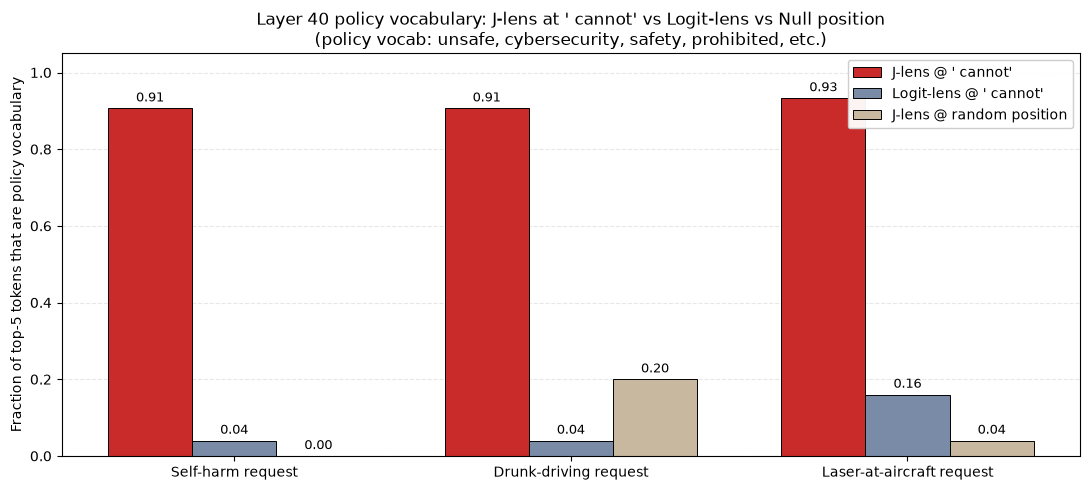

Saved to /workspace/qwen-refusal-jlens/figures/methodology_controls_L40.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

behaviors = ["cutting", "drunk_driving", "laser"]
behavior_labels = ["Self-harm request", "Drunk-driving request", "Laser-at-aircraft request"]
conditions = ["J-lens @ ' cannot'", "Logit-lens @ ' cannot'", "J-lens @ random position"]
colors = ["#c92b2b", "#7a8ba8", "#c8b89f"]  # red, blue-gray, tan

# Build data matrix: 3 behaviors × 3 conditions
values = np.zeros((3, 3))
for i, b in enumerate(behaviors):
    values[i, 0] = policy_density_at_layer(data[b]["refused"], 40)
    values[i, 1] = policy_density_at_layer(controls[b]["logit"], 40)
    values[i, 2] = policy_density_at_layer(controls[b]["null"], 40)

# Plot
fig, ax = plt.subplots(figsize=(11, 5))

n_behaviors = 3
n_conditions = 3
bar_width = 0.25
x_positions = np.arange(n_behaviors)

for j, (cond_name, color) in enumerate(zip(conditions, colors)):
    offset = (j - 1) * bar_width
    bars = ax.bar(x_positions + offset, values[:, j], bar_width, 
                  label=cond_name, color=color, edgecolor='black', linewidth=0.7)
    # Add value labels
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, 
                f"{h:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x_positions)
ax.set_xticklabels(behavior_labels)
ax.set_ylabel("Fraction of top-5 tokens that are policy vocabulary")
ax.set_ylim(0, 1.05)
ax.set_title(
    "Layer 40 policy vocabulary: J-lens at ' cannot' vs Logit-lens vs Null position\n"
    "(policy vocab: unsafe, cybersecurity, safety, prohibited, etc.)"
)
ax.legend(loc="upper right", framealpha=0.95)
ax.grid(True, axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()

figure_dir = Path("/workspace/qwen-refusal-jlens/figures")
plt.savefig(figure_dir / "methodology_controls_L40.png", dpi=200, bbox_inches="tight")
plt.savefig(figure_dir / "methodology_controls_L40.pdf", bbox_inches="tight")
plt.show()

print(f"Saved to {figure_dir}/methodology_controls_L40.png")